# 004 — From raw score to 0-1 risk

Step 1.4. `score_samples` gives numbers like -0.58 where *lower* is worse. The API needs a number where **higher = more suspicious** and the value is **always in [0, 1]**.

**Definition:** `risk(x)` = share of normal training transactions that look *more normal* than `x`. So flagging every transaction with `risk >= t` should flag about `1 - t` of normal traffic.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import settings
from src.ml.preprocess import load_splits
from src.ml.train import fit_risk_model

pd.set_option("display.float_format", "{:.4f}".format)

## 2. Fit the forest and calibrate it

In [2]:
X_train, X_test, y_train, y_test = load_splits()

start = time.perf_counter()
risk_model = fit_risk_model(X_train, y_train)
reference = risk_model.calibrator.reference_scores
print(f"fit + calibrate in {time.perf_counter() - start:.1f}s")
print(f"reference: {reference.size:,} normal training scores ({reference.nbytes / 1e6:.1f} MB)")

fit + calibrate in 5.9s
reference: 226,602 normal training scores (1.8 MB)


## 3. Score the test set

In [3]:
raw = risk_model.raw_scores(X_test)
risk = risk_model.calibrator.transform(raw)  # same as risk_model.risk(X_test), without scoring twice

results = pd.DataFrame({"raw_score": raw, "risk": risk, "Class": y_test.to_numpy()}, index=X_test.index)
print(f"risk range: {risk.min():.6f} to {risk.max():.6f}")
results.groupby("Class")["risk"].describe()

risk range: 0.000004 to 1.000000


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,56651.0000,0.5000,0.2892,0.0000,0.2489,0.4991,0.7504,1.0000
1,95.0000,0.9381,0.1482,0.1311,0.9763,0.9908,0.9977,0.9999


## 4. Some example rows

In [4]:
examples = pd.concat([
    results[results["Class"] == 0].sample(5, random_state=settings.random_seed),
    results[results["Class"] == 1].sample(5, random_state=settings.random_seed),
])
examples.assign(risk=examples["risk"].map("{:.5f}".format))

,raw_score,risk,Class
171494,-0.4075,0.54590,0
276856,-0.5362,0.97855,0
43174,-0.3901,0.30143,0
77080,-0.4496,0.86805,0
240619,-0.3930,0.34544,0
56464,-0.3941,0.36223,1
228865,-0.5726,0.98871,1
162967,-0.5428,0.98076,1
93461,-0.4212,0.69056,1
115676,-0.5314,0.97686,1


## 5. The ranking is unchanged

In [5]:
spearman = results["raw_score"].corr(results["risk"], method="spearman")
print(f"Spearman rank correlation, raw vs risk: {spearman:.6f}")
print("(-1 means exactly the same ordering, reversed)")

Spearman rank correlation, raw vs risk: -1.000000
(-1 means exactly the same ordering, reversed)


## 6. Does a threshold really equal an alert budget?

The calibration used *training* normals. This check uses *test* normals the model never saw.

In [6]:
test_normal = results.loc[results["Class"] == 0, "risk"]
test_fraud = results.loc[results["Class"] == 1, "risk"]

pd.DataFrame([
    {
        "threshold": threshold,
        "expected_normal_flagged_%": (1 - threshold) * 100,
        "actual_normal_flagged_%": (test_normal >= threshold).mean() * 100,
        "fraud_caught": f"{(test_fraud >= threshold).sum()} of {len(test_fraud)}",
    }
    for threshold in [0.9, 0.99, 0.995, 0.999]
])

,threshold,expected_normal_flagged_%,actual_normal_flagged_%,fraud_caught
0,0.9000,10.0000,10.0210,80 of 95
1,0.9900,1.0000,1.0768,51 of 95
2,0.9950,0.5000,0.5331,35 of 95
3,0.9990,0.1000,0.1218,11 of 95


## 7. What the distributions look like

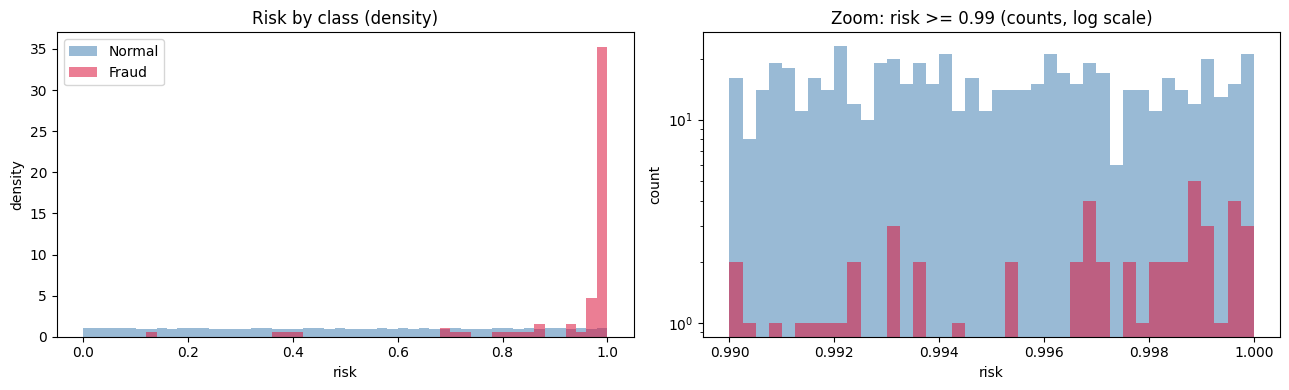

In [7]:
fig, (full, zoom) = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, "steelblue", "Normal"), (1, "crimson", "Fraud")]:
    subset = results.loc[results["Class"] == label, "risk"]
    full.hist(subset, bins=np.linspace(0, 1, 51), density=True, alpha=0.55, color=color, label=name)
    zoom.hist(subset, bins=np.linspace(0.99, 1, 41), alpha=0.55, color=color, label=name)

full.set(title="Risk by class (density)", xlabel="risk", ylabel="density")
zoom.set(title="Zoom: risk >= 0.99 (counts, log scale)", xlabel="risk", ylabel="count", yscale="log")
full.legend()
plt.tight_layout()
plt.show()

## 8. Why not a simpler mapping?

Same raw scores, three ways to squeeze them into [0, 1]. Look at what a threshold of 0.5 means in each.

In [8]:
schemes = {
    "min-max over normal training scores": np.clip((reference.max() - raw) / (reference.max() - reference.min()), 0, 1),
    "paper score (-score_samples)": -raw,
    "percentile vs normal traffic (ours)": risk,
}
is_fraud = results["Class"].to_numpy() == 1

pd.DataFrame([
    {
        "scheme": name,
        "normal_median": np.median(values[~is_fraud]),
        "fraud_median": np.median(values[is_fraud]),
        "normal_flagged_at_0.5_%": (values[~is_fraud] >= 0.5).mean() * 100,
        "fraud_caught_at_0.5": int((values[is_fraud] >= 0.5).sum()),
    }
    for name, values in schemes.items()
]).set_index("scheme")

,normal_median,fraud_median,normal_flagged_at_0.5_%,fraud_caught_at_0.5
scheme,,,,
min-max over normal training scores,0.1206,0.5775,1.7228,62
paper score (-score_samples),0.4038,0.5821,4.0847,76
percentile vs normal traffic (ours),0.4991,0.9908,49.9038,91


## Step 1.4 findings

**Definition works as specified**
- Risk on the test set ranges from **0.000004 to 1.0**, always inside [0, 1].
- Spearman rank correlation between raw score and risk is **-1.000000**: the ordering is identical, only flipped. Precision, recall and PR-AUC will be exactly what the raw scores would give.

**How the two classes look**
- Normal test traffic has mean risk **0.500**, spread evenly across 0-1. That is by construction: risk is a percentile of normal traffic.
- Fraud has median risk **0.991**, and 75% of fraud scores above **0.976**.
- Some fraud looks completely normal: the lowest fraud risk is **0.131**. No threshold will catch it.

**A threshold really is an alert budget** (checked on test normals the calibrator never saw)

| threshold | expected normal flagged | actual | fraud caught |
|---|---|---|---|
| 0.90 | 10.0% | 10.02% | 80 of 95 |
| 0.99 | 1.0% | 1.08% | 51 of 95 |
| 0.995 | 0.5% | 0.53% | 35 of 95 |
| 0.999 | 0.1% | 0.12% | 11 of 95 |

The budget holds closely. At the far tail it runs slightly over (0.12% vs 0.10%, 69 rows vs 57 expected). That is within sampling noise for so few rows, but treat the budget as approximate and confirm the final threshold on test data in Step 1.6.

**Why this mapping and not a simpler one** (same raw scores, threshold 0.5)
- Min-max scaling flags 1.7% of normal traffic; the paper's anomaly score flags 4.1%; ours flags 49.9%.
- With min-max or the paper's score, a threshold has no fixed meaning and would shift every time the model is retrained. With ours, `risk >= t` always means "flag about (1 - t) of normal traffic".

**Action for Step 1.6:** `REVIEW_THRESHOLD=0.50` and `FLAG_THRESHOLD=0.70` in `.env` were placeholders. On this scale they would send **50%** and **30%** of all normal traffic to review and blocking. Step 1.6 replaces them with values chosen from the precision/recall trade-off (likely around 0.99 and above).